# Feature extraction

This recipe shows how to engineer features for online machine learning. We'll use a price prediction task as a running example: given OHLCV candle data, can we predict whether the next candle closes higher or lower?

Along the way we'll cover River's core feature extraction tools: `compose.FuncTransformer`, `feature_extraction.Agg`, streaming statistics, and how to use [TA-Lib's streaming API](https://ta-lib.github.io/ta-lib-python/) inside a River pipeline.

## Fetching data

We'll generate synthetic 1-minute OHLCV candle data using geometric Brownian motion to simulate realistic price movements.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.RandomState(42)
n_candles = 1000
price = 50_000.0
rows = []
ts = pd.Timestamp("2026-01-01")

for _ in range(n_candles):
    ret = rng.normal(0, 0.001)
    o = price
    c = o * (1 + ret)
    h = max(o, c) * (1 + abs(rng.normal(0, 0.0005)))
    l = min(o, c) * (1 - abs(rng.normal(0, 0.0005)))
    vol = rng.exponential(10)
    rows.append([ts, o, h, l, c, vol])
    price = c
    ts += pd.Timedelta(minutes=1)

df = pd.DataFrame(rows, columns=["timestamp", "open", "high", "low", "close", "volume"])

# Target: did the next candle close higher?
df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
df = df.iloc[:-1]  # drop last row (no future candle)

print(f"Generated {len(df)} candles")
df.head()

Generated 999 candles


,timestamp,open,high,low,close,volume,target
0,2026-01-01 00:00:00,50000.000000,50028.294032,49983.807787,50024.835708,1.696249,1
1,2026-01-01 00:01:00,50024.835708,50108.015153,49999.560277,50101.025026,12.312501,0
2,2026-01-01 00:02:00,50101.025026,50114.616433,50065.900477,50077.503878,3.627537,0
3,2026-01-01 00:03:00,50077.503878,50142.918845,50030.396306,50054.181294,3.442230,0
4,2026-01-01 00:04:00,50054.181294,50062.045991,49980.782678,50003.484862,6.089347,0


## River's feature extraction building blocks

In River, each sample is a Python `dict`. Feature extraction means writing functions or classes that transform one dict into another. Let's look at the key tools.

### Streaming statistics

The `stats` module provides statistics that update one observation at a time. Each exposes `update(x)` and `get()`:

In [2]:
from river import stats

mean = stats.Mean()
for value in [1.0, 2.0, 3.0, 4.0, 5.0]:
    mean.update(value)

mean.get()

3.0

For windowed computations, wrap any compatible statistic with `utils.Rolling`:

In [3]:
from river import utils

rolling_mean = utils.Rolling(stats.Mean(), window_size=3)
for value in [1.0, 2.0, 3.0, 4.0, 5.0]:
    rolling_mean.update(value)

rolling_mean.get()  # mean of last 3 values: (3 + 4 + 5) / 3

4.0

For time-based windows, use `utils.TimeRolling` with a `timedelta` period.

### FuncTransformer

`compose.FuncTransformer` wraps any function that maps a dict to a dict, making it usable in a pipeline:

In [4]:
from river import compose

def add_return(x):
    return {**x, "return": (x["close"] - x["open"]) / x["open"]}

def add_range(x):
    return {**x, "range_pct": (x["high"] - x["low"]) / x["close"]}

transformer = compose.FuncTransformer(add_return) | compose.FuncTransformer(add_range)

x = {"open": 100.0, "high": 105.0, "low": 98.0, "close": 103.0}
transformer.transform_one(x)

{'open': 100.0,
 'high': 105.0,
 'low': 98.0,
 'close': 103.0,
 'return': 0.03,
 'range_pct': 0.06796116504854369}

### Agg

`feature_extraction.Agg` computes a running statistic over a feature, optionally grouped by another feature:

In [5]:
from river import feature_extraction

agg = feature_extraction.Agg(
    on="volume",
    by="hour",
    how=stats.Mean(),
)

for hour, vol in [(9, 1000), (9, 1200), (10, 800), (9, 1100)]:
    x = {"hour": hour, "volume": vol}
    print(f"hour={hour}, volume={vol} -> {agg.transform_one(x)}")
    agg.learn_one(x)

hour=9, volume=1000 -> {'volume_mean_by_hour': 0.0}
hour=9, volume=1200 -> {'volume_mean_by_hour': 1000.0}
hour=10, volume=800 -> {'volume_mean_by_hour': 0.0}
hour=9, volume=1100 -> {'volume_mean_by_hour': 1100.0}


## Online feature extraction with TA-Lib streaming

TA-Lib has a `talib.stream` module where each function takes an array but returns only the **latest** value as a scalar. This is perfect for online learning: we maintain a rolling buffer of recent prices and call `talib.stream` each tick to get the current indicator value.

We can wrap this pattern in a River `Transformer`:

In [6]:
import collections

import numpy as np
import talib.stream as tas
from river import base


class TALibFeatures(base.Transformer):
    """Extract technical indicators using talib.stream.

    Maintains rolling buffers of OHLCV data and computes indicators
    incrementally using TA-Lib's streaming API.
    """

    def __init__(self, buffer_size=50):
        self.buffer_size = buffer_size
        self.close_buf = collections.deque(maxlen=buffer_size)
        self.high_buf = collections.deque(maxlen=buffer_size)
        self.low_buf = collections.deque(maxlen=buffer_size)

    def learn_one(self, x, y=None):
        self.close_buf.append(x["close"])
        self.high_buf.append(x["high"])
        self.low_buf.append(x["low"])

    def transform_one(self, x):
        out = {
            "return": (x["close"] - x["open"]) / x["open"],
            "range_pct": (x["high"] - x["low"]) / x["close"],
        }

        if len(self.close_buf) >= 15:
            close = np.array(self.close_buf)
            high = np.array(self.high_buf)
            low = np.array(self.low_buf)

            out["rsi"] = tas.RSI(close, timeperiod=14)
            out["atr_pct"] = tas.ATR(high, low, close, timeperiod=14) / x["close"]

        if len(self.close_buf) >= 34:
            close = np.array(self.close_buf)
            macd, signal, hist = tas.MACD(close, 12, 26, 9)
            out["macd_hist"] = hist

        return out

A few things to note:

- `learn_one` appends to the buffers — this is called during training to keep the buffer current.
- `transform_one` computes features from the current buffer state. Features that need more history (like MACD needing 34 bars) are only included once enough data has accumulated.
- The `deque(maxlen=...)` automatically evicts old data, keeping memory bounded.

Let's verify it works on a single sample:

In [7]:
ta = TALibFeatures(buffer_size=50)

# Feed some history
for _, row in df.head(20).iterrows():
    x = row.to_dict()
    ta.learn_one(x)

# Now transform the next sample
x = df.iloc[20].to_dict()
ta.transform_one(x)

{'return': -3.5826039109905045e-05,
 'range_pct': 0.002128049731109441,
 'rsi': 53.74389054881333,
 'atr_pct': 0.0013341485350098373}

## Putting it together: an online pipeline

We can now wire `TALibFeatures` into a full River pipeline with scaling and a classifier. We'll use the prequential (test-then-train) protocol: predict first, then learn.

In [8]:
from river import linear_model, metrics, optim, preprocessing, stream

model = (
    TALibFeatures(buffer_size=50)
    | preprocessing.StandardScaler()
    | linear_model.LogisticRegression(optimizer=optim.SGD(0.01))
)

rolling_acc = utils.Rolling(metrics.Accuracy(), window_size=100)
cumulative_acc = metrics.Accuracy()

rolling_history = []

for x, y in stream.iter_pandas(
    df[["open", "high", "low", "close", "volume"]],
    df["target"],
):
    y_pred = model.predict_one(x)
    if y_pred is not None:
        rolling_acc.update(y, y_pred)
        cumulative_acc.update(y, y_pred)
    rolling_history.append(rolling_acc.get() if rolling_acc.get() else None)
    model.learn_one(x, y)

print(f"Cumulative accuracy: {cumulative_acc.get():.2%}")

Cumulative accuracy: 49.75%


Let's visualize the rolling accuracy alongside the price chart:

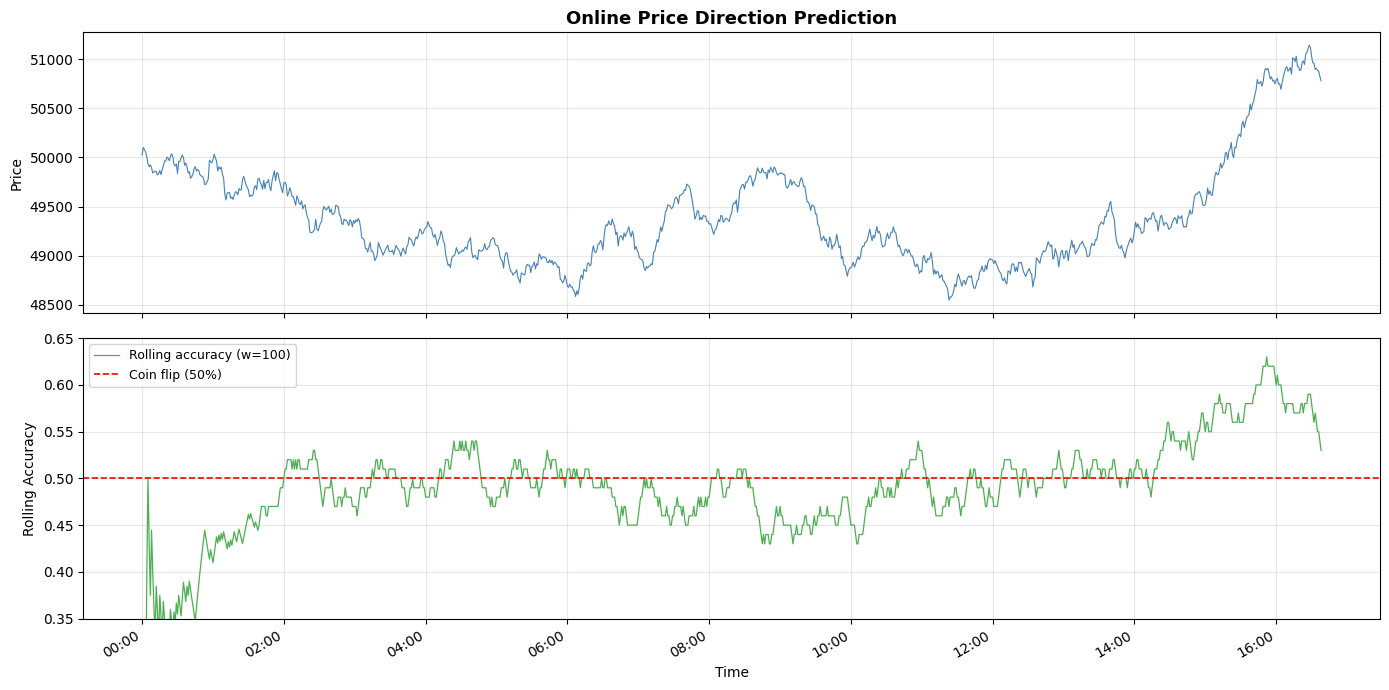

In [9]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

timestamps = df["timestamp"]

ax1.plot(timestamps, df["close"], color="steelblue", linewidth=0.8)
ax1.set_ylabel("Price")
ax1.set_title(
    "Online Price Direction Prediction",
    fontsize=13,
    fontweight="bold",
)
ax1.grid(alpha=0.3)

valid = [(t, a) for t, a in zip(timestamps, rolling_history) if a is not None]
ts, accs = zip(*valid)
ax2.plot(ts, accs, color="#4CAF50", linewidth=0.9, label="Rolling accuracy (w=100)")
ax2.axhline(y=0.5, color="red", linestyle="--", linewidth=1.2, label="Coin flip (50%)")
ax2.set_ylabel("Rolling Accuracy")
ax2.set_xlabel("Time")
ax2.set_ylim(0.35, 0.65)
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()